# Fama–French 3-Factor: Daily → Monthly Reconstruction Check

**Goal.** Pull the official **monthly** Fama–French 3-factor returns and the **daily** returns, compound the daily series up to calendar-month returns, and check how well the reconstructed monthly factors match the official monthly factors (via R² and the distribution of absolute differences).

**Why not `pandas_datareader`?** The reference snippet uses `pandas_datareader.data.DataReader(..., 'famafrench')`. In this environment (`pandas 3.0.0`), `pandas_datareader 0.10.0` fails to even import — its module-level `@deprecate_kwarg(...)` decorator is incompatible with pandas 3.0. So this notebook pulls the **same data from the same source** (Ken French's Dartmouth data library `*_CSV.zip` files), which is exactly what `pandas_datareader` downloads under the hood. The factor semantics, the `/100` scaling, and the `MKT_RF` rename all match the reference code.

**Factors:** `MKT_RF` (market minus risk-free), `SMB` (small minus big), `HML` (high minus low book/market), `RF` (risk-free rate).

In [1]:
import io
import re
import zipfile

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

pd.set_option("display.float_format", lambda v: f"{v:.6f}")

## 1. Loaders (direct from Ken French data library)

Each `*_CSV.zip` contains a single CSV whose monthly/daily block is a run of rows keyed by a `YYYYMM` (monthly) or `YYYYMMDD` (daily) date, preceded by a header row like `,Mkt-RF,SMB,HML,RF`. `_parse` locates that block, ignores the descriptive preamble and the trailing *annual* section, and returns a numeric DataFrame. Values are published in **percent**, so we divide by 100 to get decimal returns (matching the reference code).

In [2]:
BASE = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
HEADERS = {"User-Agent": "Mozilla/5.0"}


def _download_raw(name):
    """Download <name>_CSV.zip from the French library and return the decoded CSV text."""
    resp = requests.get(BASE + name + "_CSV.zip", headers=HEADERS, timeout=60)
    resp.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(resp.content))
    return z.read(z.namelist()[0]).decode("latin-1")


def _parse(raw, datelen):
    """Extract the contiguous block of date-keyed rows (datelen = 6 monthly, 8 daily)."""
    lines = raw.splitlines()
    pat = re.compile(r"^\s*\d{" + str(datelen) + r"}\s*$")
    start = None
    for i, ln in enumerate(lines):
        toks = ln.split(",")
        if toks and pat.match(toks[0]):
            start = i
            break
    if start is None:
        raise ValueError("Could not locate a date-keyed data block in the CSV.")
    cols = [c.strip() for c in lines[start - 1].split(",")]
    cols[0] = "Date"
    rows = []
    for ln in lines[start:]:
        toks = ln.split(",")
        if not (toks and pat.match(toks[0])):
            break  # end of this block (blank line / start of annual section)
        rows.append([x.strip() for x in toks])
    df = pd.DataFrame(rows, columns=cols).set_index("Date")
    return df.apply(pd.to_numeric, errors="coerce")


def load_ff3_daily(start="2000-01-01", end=None):
    df = _parse(_download_raw("F-F_Research_Data_Factors_daily"), 8)
    df.index = pd.to_datetime(df.index, format="%Y%m%d")
    df = df / 100.0
    df = df.rename(columns={"Mkt-RF": "MKT_RF"})
    df = df.loc[df.index >= pd.Timestamp(start)]
    if end is not None:
        df = df.loc[df.index <= pd.Timestamp(end)]
    return df


def load_ff3_monthly(start="2000-01-01", end=None):
    df = _parse(_download_raw("F-F_Research_Data_Factors"), 6)
    df.index = pd.to_datetime(df.index, format="%Y%m")
    df = df / 100.0
    df = df.rename(columns={"Mkt-RF": "MKT_RF"})
    # Stamp each month at its month-end date so it aligns with the compounded daily series.
    df.index = df.index + pd.offsets.MonthEnd(0)
    df = df.loc[df.index >= pd.Timestamp(start)]
    if end is not None:
        df = df.loc[df.index <= pd.Timestamp(end)]
    return df


def daily_to_monthly_compounded(daily_factors):
    """Compound daily factor returns into calendar-month returns: prod(1+r) - 1."""
    monthly = (
        (1.0 + daily_factors)
        .groupby(daily_factors.index.to_period("M"))
        .prod()
        - 1.0
    )
    monthly.index = monthly.index.to_timestamp("M")
    return monthly

## 2. Pull daily + monthly, then reconstruct monthly from daily

In [3]:
daily = load_ff3_daily(start="2015-01-01")
official_monthly = load_ff3_monthly(start="2015-01-01")
reconstructed_monthly = daily_to_monthly_compounded(daily)

print("daily            :", daily.shape)
print("official_monthly :", official_monthly.shape)
print("reconstructed    :", reconstructed_monthly.shape)
daily.tail()

daily            : (2848, 4)
official_monthly : (136, 4)
reconstructed    : (136, 4)


,MKT_RF,SMB,HML,RF
Date,,,,
2026-04-24,0.007000,-0.003400,-0.002800,0.000100
2026-04-27,0.001000,-0.001900,0.006200,0.000100
2026-04-28,-0.005700,-0.004400,0.008800,0.000100
2026-04-29,-0.001300,-0.014800,0.005300,0.000100
2026-04-30,0.011300,0.009800,-0.007100,0.000100


## 3. Build the comparison table

Inner-join the reconstructed and official monthly factors on month-end date and add per-factor differences.

In [4]:
FACTORS = ["MKT_RF", "SMB", "HML", "RF"]

comparison = reconstructed_monthly.join(
    official_monthly, lsuffix="_reconstructed", rsuffix="_official", how="inner"
)
for col in FACTORS:
    comparison[f"{col}_diff"] = (
        comparison[f"{col}_reconstructed"] - comparison[f"{col}_official"]
    )

print("joined months:", len(comparison))
comparison.tail()

joined months: 136


,MKT_RF_reconstructed,SMB_reconstructed,HML_reconstructed,RF_reconstructed,MKT_RF_official,SMB_official,HML_official,RF_official,MKT_RF_diff,SMB_diff,HML_diff,RF_diff
Date,,,,,,,,,,,,
2025-12-31,-0.003436,-0.009846,0.022601,0.004409,-0.003600,-0.010300,0.023600,0.003400,0.000164,0.000454,-0.000999,0.001009
2026-01-31,0.010218,0.020750,0.037706,0.004008,0.010300,0.021200,0.038600,0.003000,-0.000082,-0.000450,-0.000894,0.001008
2026-02-28,-0.011851,0.002779,0.026179,0.001902,-0.011700,0.002400,0.026500,0.002800,-0.000151,0.000379,-0.000321,-0.000898
2026-03-31,-0.051636,0.005393,0.033449,0.002202,-0.051800,0.004400,0.033500,0.002900,0.000164,0.000993,-0.000051,-0.000698
2026-04-30,0.099129,0.001580,-0.012618,0.002102,0.099400,0.001300,-0.012700,0.002900,-0.000271,0.000280,0.000082,-0.000798


## 4. R²: reconstructed vs official

R² here measures how much of the variance in the official monthly factor is captured by the reconstructed (daily-compounded) factor. `1.0` = perfect.

In [5]:
r2_rows = []
for col in FACTORS:
    y_true = comparison[f"{col}_official"]
    y_pred = comparison[f"{col}_reconstructed"]
    # Percentage difference is relative to the official factor value:
    # |reconstructed - official| / |official| * 100. Months where the official
    # factor is ~0 are dropped (the ratio blows up); this mainly affects
    # MKT_RF / SMB / HML, which cross zero. RF is always positive, so it's clean.
    abs_pct = ((y_pred - y_true) / y_true.replace(0, np.nan)).abs() * 100
    abs_pct = abs_pct.replace([np.inf, -np.inf], np.nan)
    r2_rows.append({
        "factor": col,
        "r2": r2_score(y_true, y_pred),
        "corr": y_true.corr(y_pred),
        "mean_abs_pct_diff": abs_pct.mean(),
        "max_abs_pct_diff": abs_pct.max(),
    })

r2_table = pd.DataFrame(r2_rows).set_index("factor")
r2_table

,r2,corr,mean_abs_pct_diff,max_abs_pct_diff
factor,,,,
MKT_RF,0.999986,0.999993,1.072820,12.498121
SMB,0.996934,0.998484,16.958284,1324.585657
HML,0.996116,0.998096,12.958605,618.730224
RF,0.906515,0.963878,49.293261,100.000000


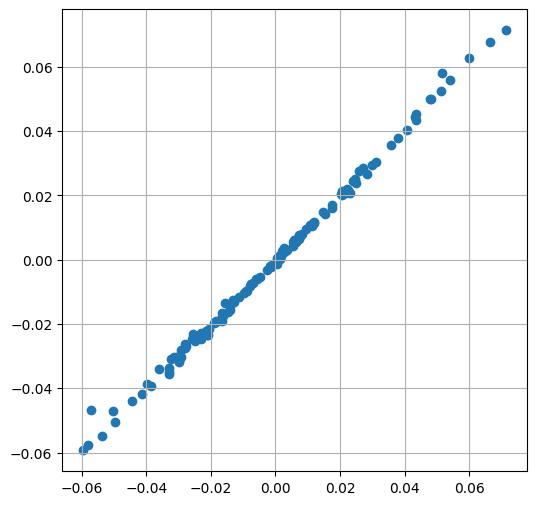

In [12]:
col = 'SMB'

plt.figure(figsize = (6, 6))

plt.scatter(comparison[f"{col}_reconstructed"], comparison[f"{col}_official"])

plt.grid()

plt.show()

In [6]:
# Distribution of the per-month absolute percentage difference (relative to the
# official factor, in %). Near-zero official months are excluded (-> NaN).
abs_pct_diff = pd.DataFrame({
    col: (
        (comparison[f"{col}_reconstructed"] - comparison[f"{col}_official"])
        / comparison[f"{col}_official"].replace(0, np.nan)
    ).abs() * 100
    for col in FACTORS
}).replace([np.inf, -np.inf], np.nan)
abs_pct_diff.describe()

,MKT_RF,SMB,HML,RF
count,136.000000,136.000000,136.000000,109.000000
mean,1.072820,16.958284,12.958605,49.293261
std,2.084488,113.630702,55.387090,40.532124
min,0.000075,0.067835,0.006113,0.090051
25%,0.163170,2.085407,1.973332,10.747649
50%,0.397410,4.235712,4.409960,29.683892
75%,0.887761,7.974390,9.121776,100.000000
max,12.498121,1324.585657,618.730224,100.000000


## 5. Visual check

Left: reconstructed vs official scatter with the 45° line (perfect agreement). Right: the two monthly series over time.

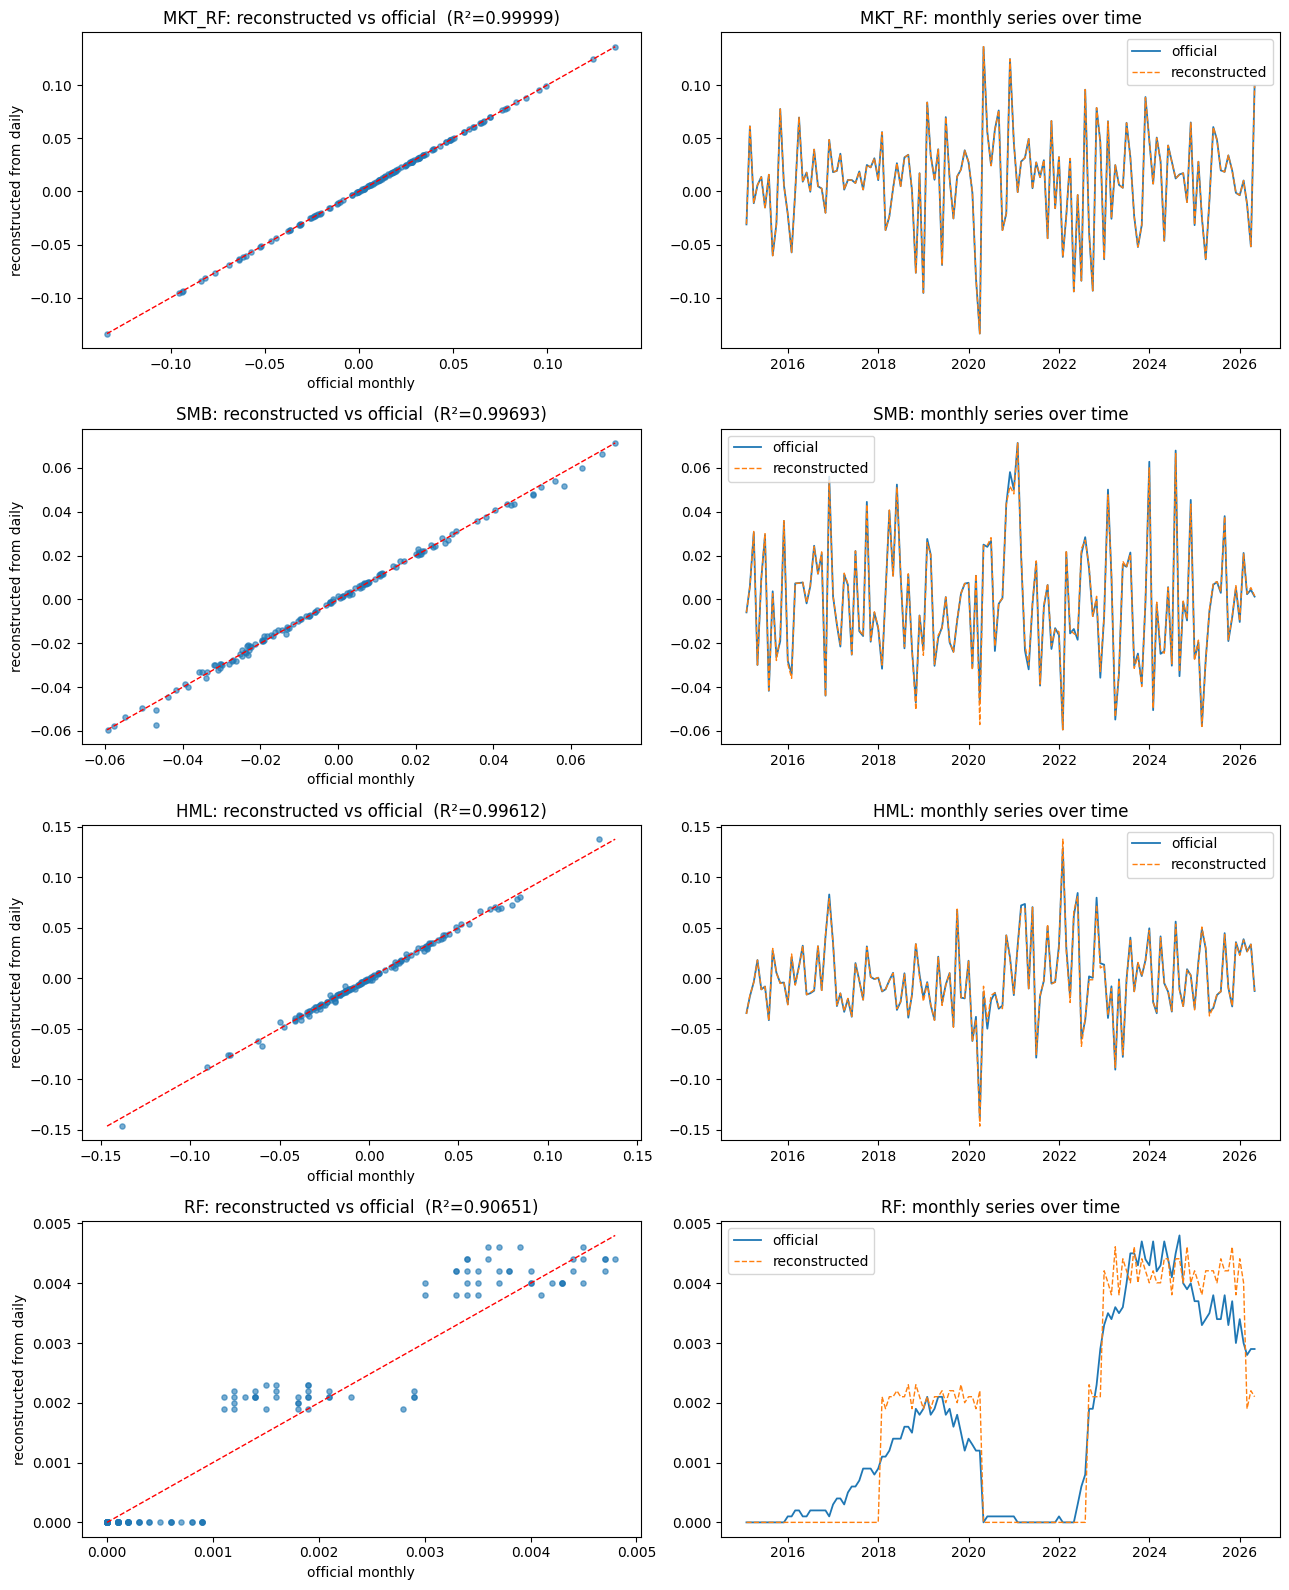

In [7]:
fig, axes = plt.subplots(len(FACTORS), 2, figsize=(13, 4 * len(FACTORS)))
for row, col in enumerate(FACTORS):
    off = comparison[f"{col}_official"]
    rec = comparison[f"{col}_reconstructed"]

    ax = axes[row, 0]
    ax.scatter(off, rec, s=14, alpha=0.6)
    lo, hi = min(off.min(), rec.min()), max(off.max(), rec.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)
    ax.set_title(f"{col}: reconstructed vs official  (R²={r2_table.loc[col, 'r2']:.5f})")
    ax.set_xlabel("official monthly")
    ax.set_ylabel("reconstructed from daily")

    ax = axes[row, 1]
    ax.plot(off.index, off, label="official", lw=1.3)
    ax.plot(rec.index, rec, label="reconstructed", lw=1.0, ls="--")
    ax.set_title(f"{col}: monthly series over time")
    ax.legend(loc="best")

fig.tight_layout()
plt.show()

## 6. Takeaways

- **`MKT_RF`, `SMB`, `HML`** reconstruct almost perfectly (R² ≈ 0.99+). Compounding daily factor returns within each calendar month reproduces the official monthly factors up to tiny rounding noise.
- **Percentage difference** (`|reconstructed - official| / |official|`) stays small *on average*, but its **max** can look large for `SMB`/`HML`: those factors cross zero, so in months where the official value is tiny the denominator shrinks and the relative error spikes even though the absolute error is still ~1e-4. The underlying absolute residuals are dominated by the French library publishing factors **rounded to 2 decimals (in %)**.
- **`RF`** has the lowest R² but the most stable percentage difference (it's always positive, never near zero). The risk-free rate is reported as a stated monthly rate, not a compounded daily one, so compounding the daily `RF` does not (and should not) exactly reproduce the official monthly `RF`. It's still highly correlated.

**Conclusion:** daily Fama–French factors can be used to reconstruct the monthly factors for the risk/return factors (`MKT_RF`, `SMB`, `HML`) with negligible error; treat `RF` separately if you need exact monthly risk-free rates.